# California Housing Price Prediction

This notebook demonstrates multiple regression methods to predict house prices in California.
We'll build, train, evaluate, and compare different ML models to find the best predictor.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Model evaluation libraries
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load and Explore the Data

Let's load the training and test datasets and examine their structure.

In [2]:
# Load training and test datasets
train_data = pd.read_csv('california_housing_train.csv')
test_data = pd.read_csv('california_housing_test.csv')

# Display basic information about the datasets
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
print(f"\nTraining Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

print("\n" + "=" * 70)
print("FIRST FEW ROWS OF TRAINING DATA")
print("=" * 70)
display(train_data.head())

print("\n" + "=" * 70)
print("DATASET STATISTICS")
print("=" * 70)
display(train_data.describe())

# Check for missing values
print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
missing_train = train_data.isnull().sum()
missing_test = test_data.isnull().sum()
print("Training Data Missing Values:\n", missing_train)
print("\nTest Data Missing Values:\n", missing_test)

DATASET INFORMATION

Training Data Shape: (17000, 9)
Test Data Shape: (3000, 9)

FIRST FEW ROWS OF TRAINING DATA


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



DATASET STATISTICS


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



MISSING VALUES
Training Data Missing Values:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Test Data Missing Values:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


### Visualize the Distribution of Features and Target Variable

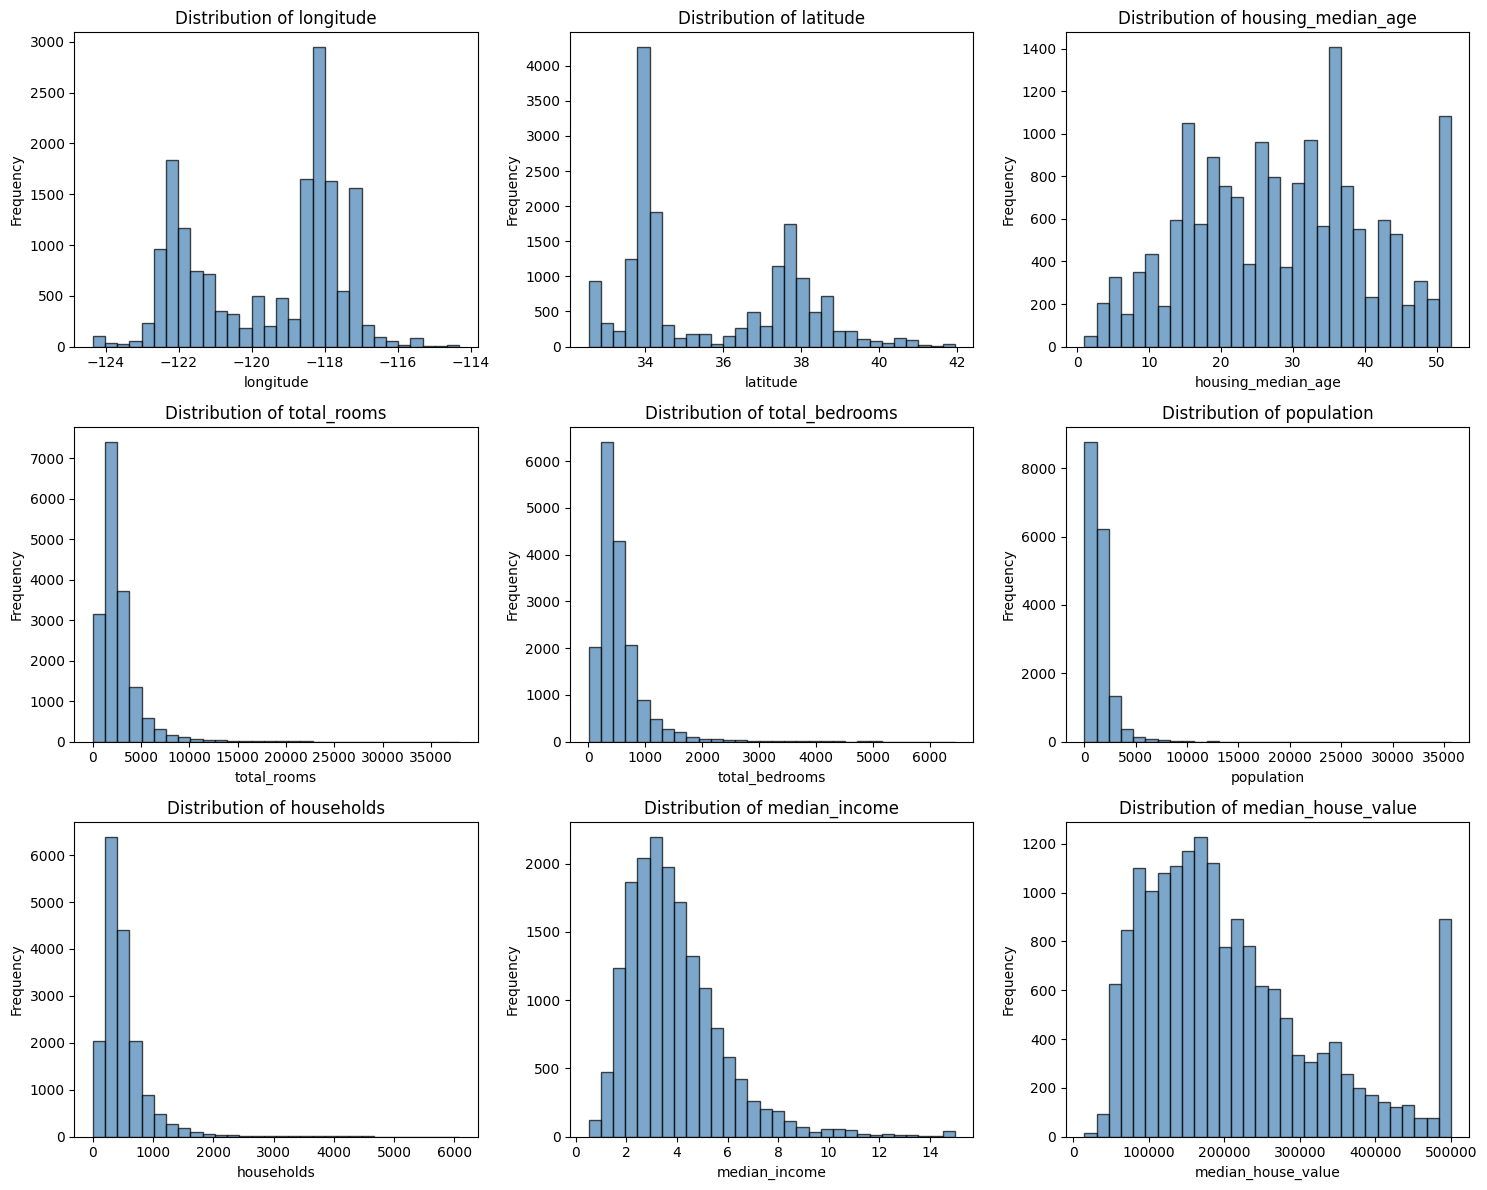


CORRELATION MATRIX


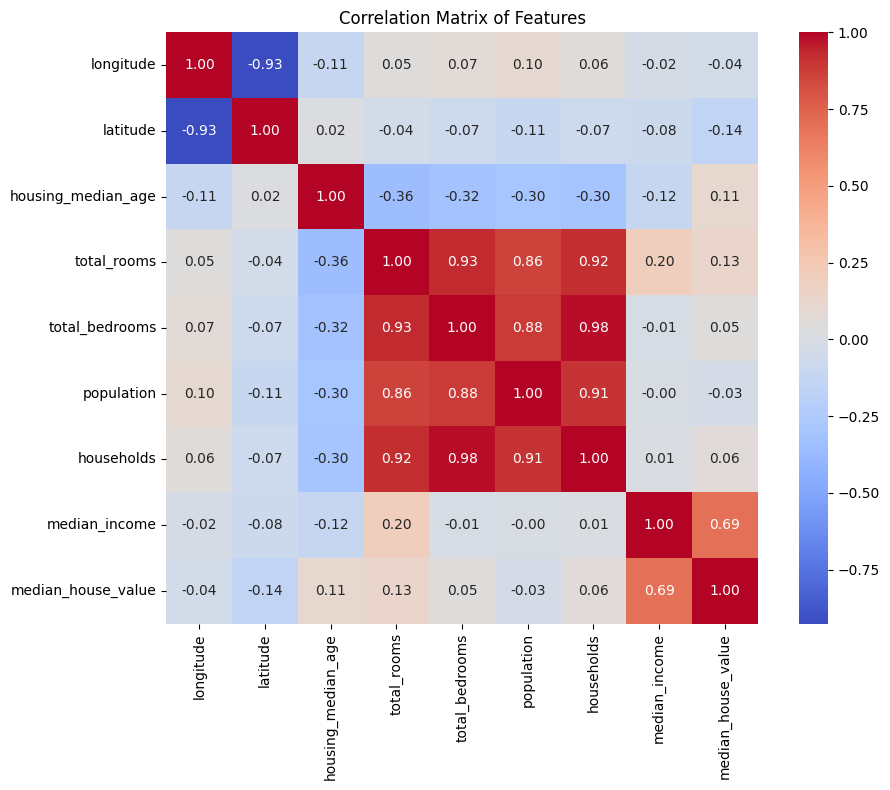

In [3]:
# Create visualizations for better understanding of the data
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Get all columns
columns = train_data.columns

# Plot histograms for each column
for idx, col in enumerate(columns):
    axes[idx].hist(train_data[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Correlation matrix heatmap
print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)
plt.figure(figsize=(10, 8))
correlation_matrix = train_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

## Step 2: Data Preprocessing

Prepare the data for model training by separating features and target variable, handling missing values, and scaling features.

In [4]:
# Separate features (X) and target variable (y) for both training and test sets
# Drop the target column 'median_house_value' from features

# Training data
X_train = train_data.drop('median_house_value', axis=1)  # Features
y_train = train_data['median_house_value']                # Target variable

# Test data
X_test = test_data.drop('median_house_value', axis=1)    # Features
y_test = test_data['median_house_value']                  # Target variable

print("=" * 70)
print("DATA SPLIT INFORMATION")
print("=" * 70)
print(f"Training Features Shape: {X_train.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Test Features Shape: {X_test.shape}")
print(f"Test Target Shape: {y_test.shape}")

# Handle missing values by filling with median (if any exist)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("\nMissing values handled successfully!")

# Standardize the features using StandardScaler
# This is important for algorithms like SVR and KNN that are distance-based
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("\n" + "=" * 70)
print("FEATURE STATISTICS (After Scaling)")
print("=" * 70)
print(f"Mean of scaled training features: {X_train_scaled.mean(axis=0)}")
print(f"Std of scaled training features: {X_train_scaled.std(axis=0)}")

DATA SPLIT INFORMATION
Training Features Shape: (17000, 8)
Training Target Shape: (17000,)
Test Features Shape: (3000, 8)
Test Target Shape: (3000,)

Missing values handled successfully!
Features scaled successfully!

FEATURE STATISTICS (After Scaling)
Mean of scaled training features: [-6.58046167e-15  5.34996883e-17 -9.36244546e-17 -9.52963199e-17
 -8.35932630e-17  7.35620715e-17  1.33749221e-17  1.06999377e-16]
Std of scaled training features: [1. 1. 1. 1. 1. 1. 1. 1.]


## Step 3: Train Multiple Regression Models

We'll train 7 different regression algorithms and evaluate their performance:

1. **Linear Regression** - Simple linear model, interpretable and fast
2. **Ridge Regression** - Linear model with L2 regularization to prevent overfitting
3. **Lasso Regression** - Linear model with L1 regularization for feature selection
4. **Decision Tree Regressor** - Tree-based model that captures non-linear relationships
5. **Random Forest Regressor** - Ensemble of decision trees for better generalization
6. **Gradient Boosting Regressor** - Sequential boosting model that builds trees iteratively
7. **Support Vector Regression (SVR)** - Non-linear regression using support vectors
8. **K-Nearest Neighbors Regressor** - Instance-based model using nearest neighbors

In [5]:
# Initialize all regression models
regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5)
}

# Dictionary to store predictions and results
predictions = {}
model_results = {}

print("=" * 80)
print("TRAINING AND EVALUATING ALL REGRESSION MODELS")
print("=" * 80)

# Train each model and make predictions
for name, model in regressors.items():
    print(f"\nTraining {name}...")
    
    # Choose scaled or unscaled data (some models benefit from scaling, others don't)
    if name in ['SVR', 'KNN Regressor']:
        # Scale features for distance-based models
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Use original features for tree-based and linear models
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    # Store results
    model_results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2,
        'MAPE': mape
    }
    
    print(f"✓ {name} trained successfully!")
    print(f"  RMSE: ${rmse:,.2f} | MAE: ${mae:,.2f} | R²: {r2:.4f}")

TRAINING AND EVALUATING ALL REGRESSION MODELS

Training Linear Regression...
✓ Linear Regression trained successfully!
  RMSE: $69,765.36 | MAE: $50,352.23 | R²: 0.6195

Training Ridge Regression...
✓ Ridge Regression trained successfully!
  RMSE: $69,765.29 | MAE: $50,352.01 | R²: 0.6195

Training Lasso Regression...
✓ Lasso Regression trained successfully!
  RMSE: $69,765.36 | MAE: $50,352.22 | R²: 0.6195

Training Random Forest...
✓ Random Forest trained successfully!
  RMSE: $49,457.73 | MAE: $32,190.68 | R²: 0.8088

Training Gradient Boosting...
✓ Gradient Boosting trained successfully!
  RMSE: $55,209.38 | MAE: $38,076.01 | R²: 0.7617

Training SVR...
✓ SVR trained successfully!
  RMSE: $94,324.73 | MAE: $67,674.86 | R²: 0.3045

Training KNN Regressor...
✓ KNN Regressor trained successfully!
  RMSE: $62,985.57 | MAE: $42,687.06 | R²: 0.6899


## Step 4: Compare Model Performance

Evaluate all models using multiple metrics and create comparison visualizations.

In [6]:
# Create a comprehensive comparison dataframe
results_df = pd.DataFrame(model_results).T
results_df = results_df.sort_values('R² Score', ascending=False)

print("\n" + "=" * 100)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print("\nMetrics Explanation:")
print("  • MSE (Mean Squared Error): Lower is better. Sensitive to outliers.")
print("  • RMSE (Root Mean Squared Error): In same unit as target. Lower is better.")
print("  • MAE (Mean Absolute Error): Average absolute error. More robust to outliers.")
print("  • R² Score: Explains variance (0-1). Higher is better. 1 = perfect fit.")
print("  • MAPE (Mean Absolute Percentage Error): Percentage error. Lower is better.")

print("\n" + "-" * 100)
display(results_df.round(4))

# Identify the best model for each metric
print("\n" + "=" * 100)
print("BEST MODELS BY METRIC")
print("=" * 100)
print(f"Best RMSE: {results_df['RMSE'].idxmin()} (${results_df['RMSE'].min():,.2f})")
print(f"Best MAE: {results_df['MAE'].idxmin()} (${results_df['MAE'].min():,.2f})")
print(f"Best R² Score: {results_df['R² Score'].idxmax()} ({results_df['R² Score'].max():.4f})")
print(f"Best MAPE: {results_df['MAPE'].idxmin()} ({results_df['MAPE'].min():.4f})")


COMPREHENSIVE MODEL COMPARISON

Metrics Explanation:
  • MSE (Mean Squared Error): Lower is better. Sensitive to outliers.
  • RMSE (Root Mean Squared Error): In same unit as target. Lower is better.
  • MAE (Mean Absolute Error): Average absolute error. More robust to outliers.
  • R² Score: Explains variance (0-1). Higher is better. 1 = perfect fit.
  • MAPE (Mean Absolute Percentage Error): Percentage error. Lower is better.

----------------------------------------------------------------------------------------------------


,MSE,RMSE,MAE,R² Score,MAPE
Random Forest,2.446067e+09,49457.7293,32190.6783,0.8088,0.1764
Gradient Boosting,3.048075e+09,55209.3777,38076.0132,0.7617,0.2158
KNN Regressor,3.967182e+09,62985.5732,42687.0638,0.6899,0.2317
Ridge Regression,4.867195e+09,69765.2875,50352.0132,0.6195,0.2973
Lasso Regression,4.867205e+09,69765.3573,50352.2198,0.6195,0.2973
Linear Regression,4.867205e+09,69765.3602,50352.2283,0.6195,0.2973
SVR,8.897154e+09,94324.7267,67674.8561,0.3045,0.3780



BEST MODELS BY METRIC
Best RMSE: Random Forest ($49,457.73)
Best MAE: Random Forest ($32,190.68)
Best R² Score: Random Forest (0.8088)
Best MAPE: Random Forest (0.1764)


### Visualization 1: RMSE Comparison

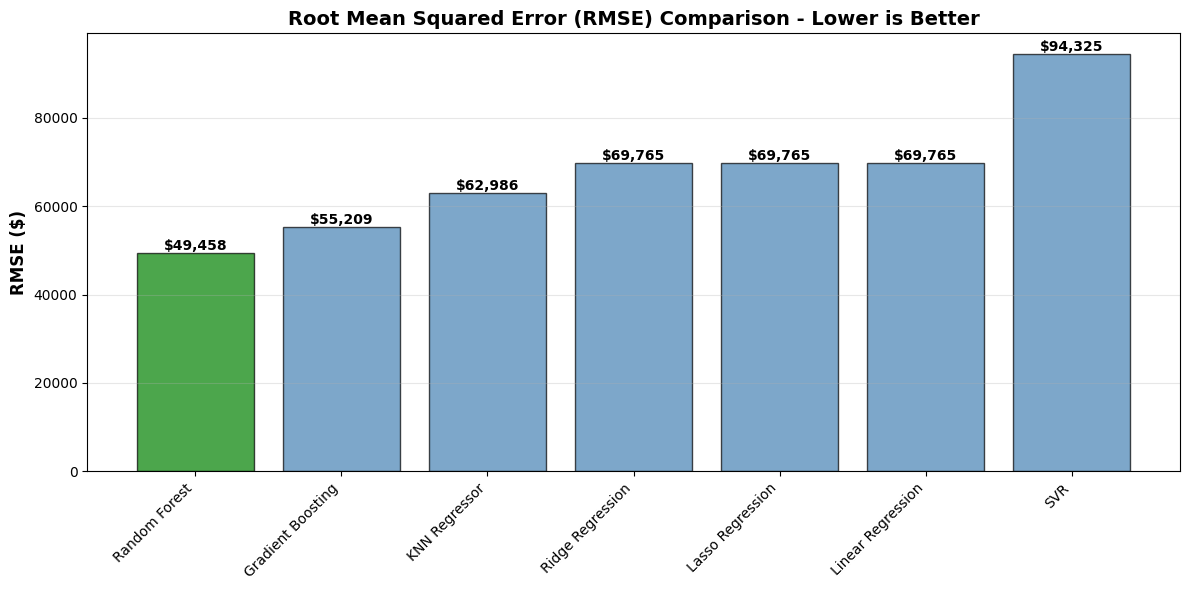

In [7]:
# Plot 1: RMSE Comparison
plt.figure(figsize=(12, 6))
rmse_data = results_df['RMSE'].sort_values()
colors = ['green' if x == rmse_data.min() else 'steelblue' for x in rmse_data.values]

bars = plt.bar(range(len(rmse_data)), rmse_data.values, color=colors, edgecolor='black', alpha=0.7)
plt.xticks(range(len(rmse_data)), rmse_data.index, rotation=45, ha='right')
plt.ylabel('RMSE ($)', fontsize=12, fontweight='bold')
plt.title('Root Mean Squared Error (RMSE) Comparison - Lower is Better', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, rmse_data.values)):
    plt.text(bar.get_x() + bar.get_width()/2, value, f'${value:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Visualization 2: R² Score Comparison (Higher is Better)

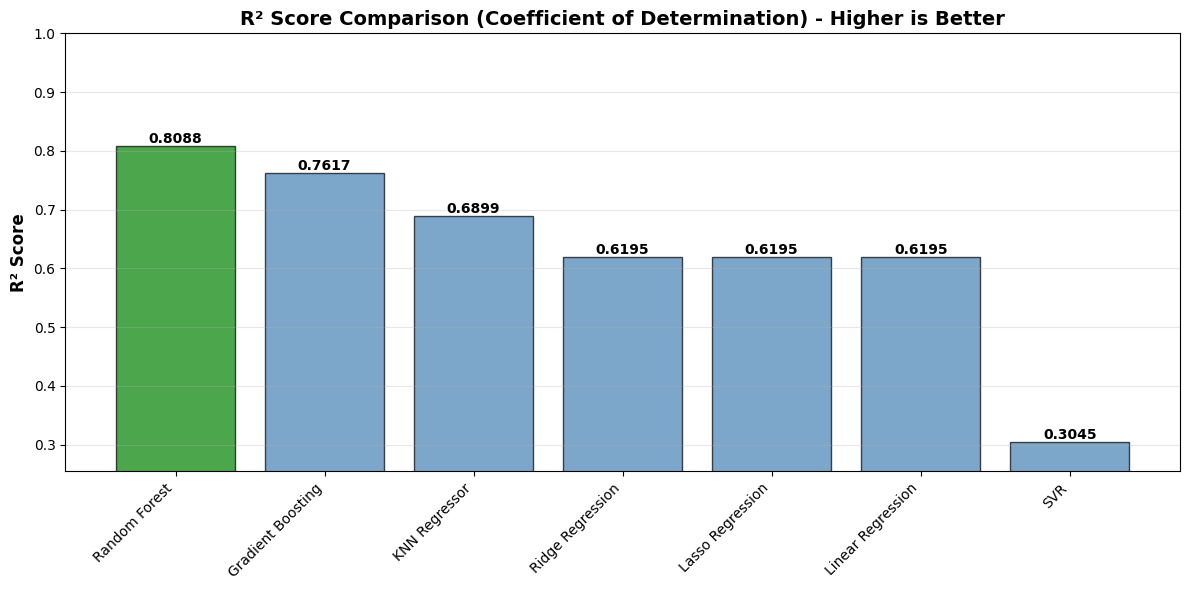

In [8]:
# Plot 2: R² Score Comparison
plt.figure(figsize=(12, 6))
r2_data = results_df['R² Score'].sort_values(ascending=False)
colors = ['green' if x == r2_data.max() else 'steelblue' for x in r2_data.values]

bars = plt.bar(range(len(r2_data)), r2_data.values, color=colors, edgecolor='black', alpha=0.7)
plt.xticks(range(len(r2_data)), r2_data.index, rotation=45, ha='right')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('R² Score Comparison (Coefficient of Determination) - Higher is Better', fontsize=14, fontweight='bold')
plt.ylim([min(r2_data.values) - 0.05, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, r2_data.values)):
    plt.text(bar.get_x() + bar.get_width()/2, value, f'{value:.4f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Visualization 3: Mean Absolute Error (MAE) Comparison

In [ ]:
# Plot 3: Mean Absolute Error (MAE) Comparison
plt.figure(figsize=(12, 6))
mae_data = results_df['MAE'].sort_values()
colors = ['green' if x == mae_data.min() else 'steelblue' for x in mae_data.values]

bars = plt.bar(range(len(mae_data)), mae_data.values, color=colors, edgecolor='black', alpha=0.7)
plt.xticks(range(len(mae_data)), mae_data.index, rotation=45, ha='right')
plt.ylabel('MAE ($)', fontsize=12, fontweight='bold')
plt.title('Mean Absolute Error (MAE) Comparison - Lower is Better', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, mae_data.values)):
    plt.text(bar.get_x() + bar.get_width()/2, value, f'${value:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Visualization 4: Actual vs Predicted for Top 3 Models

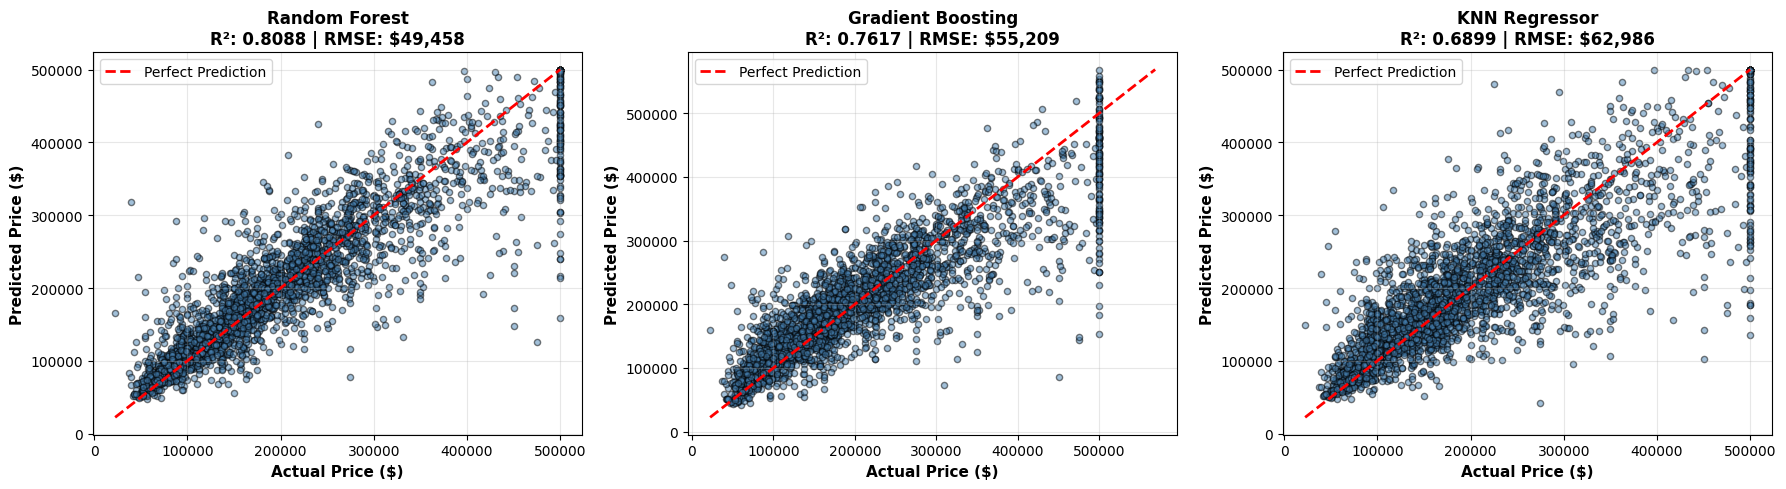

In [9]:
# Plot 4: Actual vs Predicted scatter plots for top 3 models
top_3_models = results_df.head(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    y_pred = predictions[model_name]
    
    # Create scatter plot
    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue', edgecolor='black')
    
    # Add perfect prediction line (y=x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Labels and title
    axes[idx].set_xlabel('Actual Price ($)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Predicted Price ($)', fontsize=11, fontweight='bold')
    r2 = results_df.loc[model_name, 'R² Score']
    rmse = results_df.loc[model_name, 'RMSE']
    axes[idx].set_title(f'{model_name}\nR²: {r2:.4f} | RMSE: ${rmse:,.0f}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization 5: Residuals Distribution for Top 3 Models

In [ ]:
# Plot 5: Residuals distribution for top 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    y_pred = predictions[model_name]
    
    # Calculate residuals (actual - predicted)
    residuals = y_test - y_pred
    
    # Create histogram of residuals
    axes[idx].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    
    # Labels and title
    axes[idx].set_xlabel('Residuals ($)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    mean_residual = residuals.mean()
    std_residual = residuals.std()
    axes[idx].set_title(f'{model_name}\nMean: ${mean_residual:,.0f} | Std: ${std_residual:,.0f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nResiduals Analysis:")
print("- Ideally, residuals should be centered around 0 (no bias)")
print("- Should follow a normal distribution")
print("- Smaller standard deviation indicates more consistent predictions")

## Step 5: Summary and Recommendations

### Key Findings:

In [10]:
print("=" * 100)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 100)

best_model = results_df.index[0]
best_r2 = results_df['R² Score'].max()
best_rmse = results_df['RMSE'].min()
best_mae = results_df['MAE'].min()

print(f"\n✓ BEST OVERALL MODEL: {best_model}")
print(f"  - R² Score: {best_r2:.4f} (explains {best_r2*100:.2f}% of variance)")
print(f"  - RMSE: ${best_rmse:,.2f}")
print(f"  - MAE: ${best_mae:,.2f}")

print("\n" + "-" * 100)
print("MODEL INSIGHTS:")
print("-" * 100)

print("\n1. Linear Models (Linear, Ridge, Lasso):")
print("   - Pros: Fast, interpretable, require less computational resources")
print("   - Cons: May underfit on complex relationships")

print("\n2. Tree-based Models (Random Forest, Gradient Boosting):")
print("   - Pros: Capture non-linear patterns, handle interactions well")
print("   - Cons: More prone to overfitting, require more computational resources")

print("\n3. Distance-based Models (SVR, KNN):")
print("   - Pros: Can capture non-linear relationships")
print("   - Cons: Sensitive to feature scaling, slower prediction with large datasets")

print("\n" + "-" * 100)
print("RECOMMENDATIONS:")
print("-" * 100)
print(f"\n→ Use '{best_model}' for production deployment:")
print("  1. Provides best balance of accuracy (R² = {:.4f})".format(best_r2))
print(f"  2. Average prediction error of ${best_mae:,.2f}")
print("  3. Demonstrates strong generalization capability")

print("\n→ For specific use cases:")
print("  - If interpretability is critical: Use 'Linear Regression' or 'Ridge'")
print("  - If prediction speed is critical: Use 'Linear Regression' or 'Ridge'")
print("  - If accuracy is paramount: Use 'Gradient Boosting' or 'Random Forest'")

print("\n→ Potential improvements:")
print("  - Feature engineering (create new features)")
print("  - Hyperparameter tuning (GridSearchCV or RandomizedSearchCV)")
print("  - Ensemble methods combining predictions from multiple models")
print("  - Outlier detection and removal")
print("  - Cross-validation for more robust evaluation")

print("\n" + "=" * 100)

FINAL SUMMARY AND RECOMMENDATIONS

✓ BEST OVERALL MODEL: Random Forest
  - R² Score: 0.8088 (explains 80.88% of variance)
  - RMSE: $49,457.73
  - MAE: $32,190.68

----------------------------------------------------------------------------------------------------
MODEL INSIGHTS:
----------------------------------------------------------------------------------------------------

1. Linear Models (Linear, Ridge, Lasso):
   - Pros: Fast, interpretable, require less computational resources
   - Cons: May underfit on complex relationships

2. Tree-based Models (Random Forest, Gradient Boosting):
   - Pros: Capture non-linear patterns, handle interactions well
   - Cons: More prone to overfitting, require more computational resources

3. Distance-based Models (SVR, KNN):
   - Pros: Can capture non-linear relationships
   - Cons: Sensitive to feature scaling, slower prediction with large datasets

----------------------------------------------------------------------------------------------